# Import libraries

In [6]:
import pandas as pd
import numpy as np
import json

### Using ../ to navigate from 'notbooks' up to 'research'# Load processed data

In [7]:
DATA_DIR = Path("../data/processed")

# Load processed data

In [9]:
train = pd.read_csv(DATA_DIR / "train.csv")
val   = pd.read_csv(DATA_DIR / "val.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")
with open(DATA_DIR / "meta.json", "r") as f:
    meta = json.load(f)

# Dataset Statistics

In [10]:
print("=== Dataset Statistics ===")
print(f"n_users : {meta['n_users']:,}")
print(f"n_items : {meta['n_items']:,}")
print(f"n_train : {meta['n_train']:,}")
print(f"n_val   : {meta['n_val']:,}")
print(f"n_test  : {meta['n_test']:,}")

=== Dataset Statistics ===
n_users : 6,040
n_items : 3,706
n_train : 4,940,645
n_val   : 6,040
n_test  : 6,040


# Verify no ID leakage

In [11]:
assert train.user_id.max() < meta['n_users'], "user_id out of range!"
assert train.item_id.max() < meta['n_items'], "item_id out of range!"

# Check negative ratio

In [12]:
pos = (train.label == 1).sum()
neg = (train.label == 0).sum()
print(f"\nLabel balance — pos: {pos:,} | neg: {neg:,} | ratio: 1:{neg//pos}")


Label balance — pos: 988,129 | neg: 3,952,516 | ratio: 1:4


# Check test has exactly one entry per user

In [13]:
assert len(test) == meta['n_users'], "Test should have exactly 1 row per user"

# Verify IDs are contiguous from 0

In [14]:
assert train.user_id.min() == 0
assert train.item_id.min() == 0

In [15]:
print("\nAll assertions passed — data is clean and ready for NCF.")


All assertions passed — data is clean and ready for NCF.


# Load numpy arrays (these are what the model will actually use)

In [16]:
u = np.load(DATA_DIR / "train_users.npy")
i = np.load(DATA_DIR / "train_items.npy")
l = np.load(DATA_DIR / "train_labels.npy")

In [17]:
print(f"\nNumPy arrays: users{u.shape}, items{i.shape}, labels{l.shape}")
print(f"dtype — users: {u.dtype}, items: {i.dtype}, labels: {l.dtype}")


NumPy arrays: users(4940645,), items(4940645,), labels(4940645,)
dtype — users: int64, items: int64, labels: int64


# User's interaction history

In [19]:
from IPython.display import Image, display

FIG_DIR = Path("../notebooks/figures")

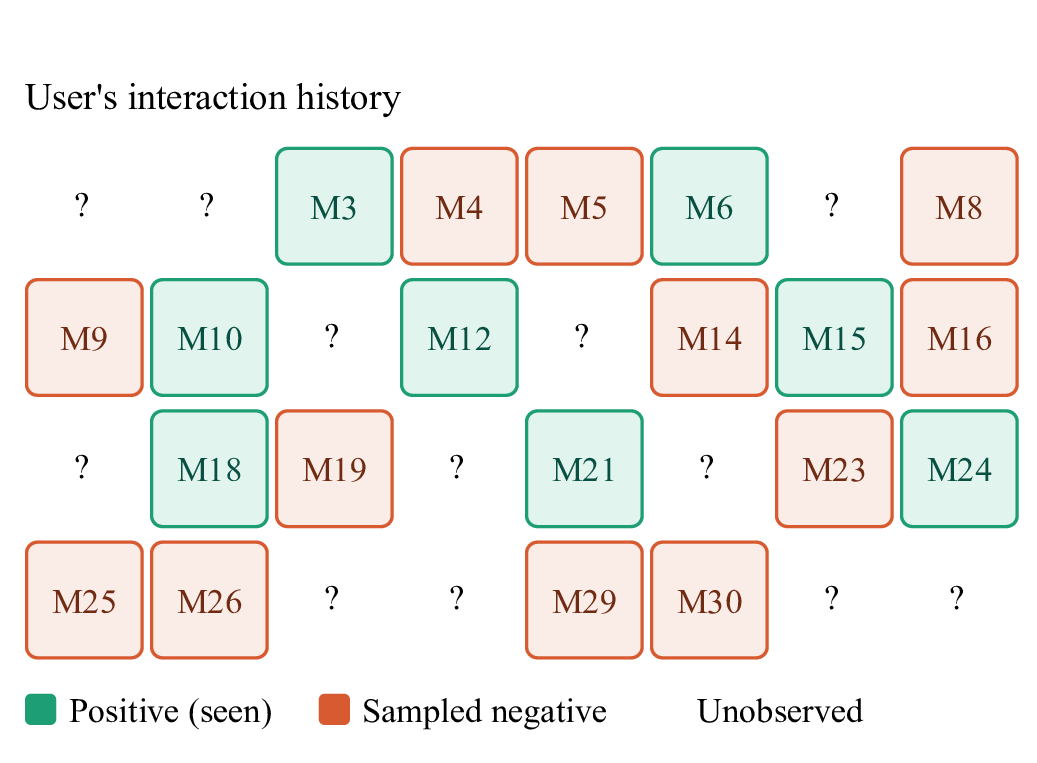

In [21]:
display(Image(filename=FIG_DIR/'User-interaction-history.png', width=500))

# Training batch (this user)

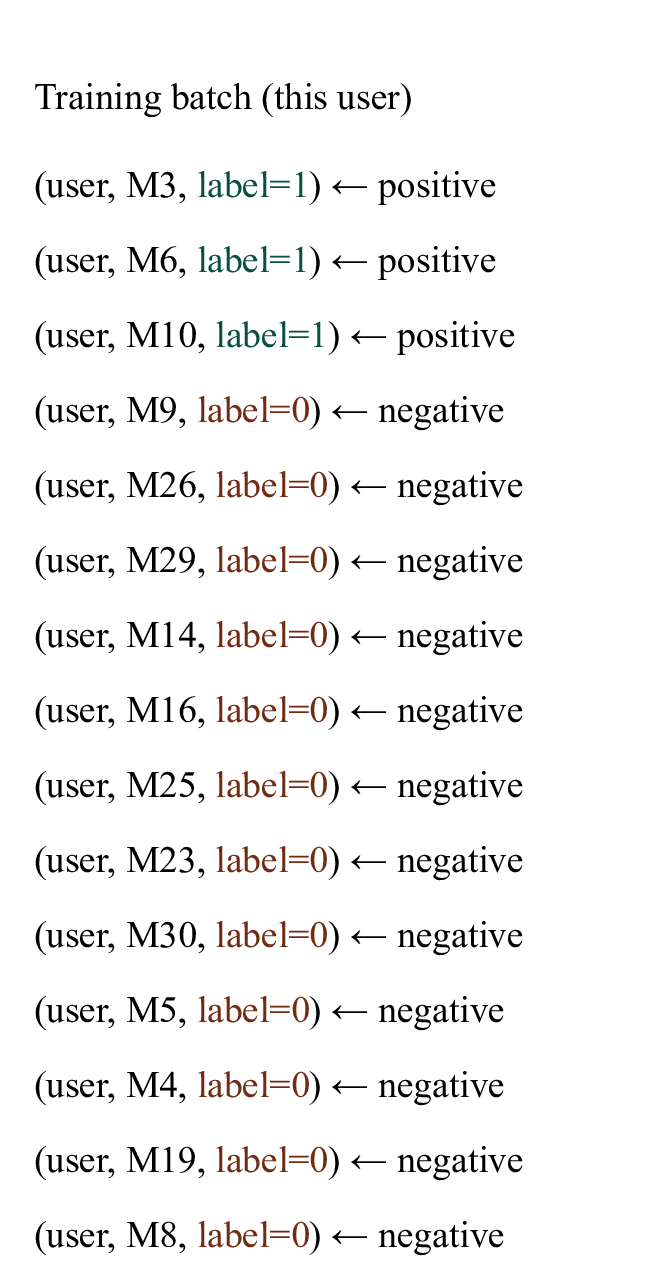

In [22]:
display(Image(filename=FIG_DIR/'Training-batch-(this user).png', width=500))